## Python machine learning (ML) methods for restaurant sales anticipation and growth analysis

In [ ]:
"""
I successfully completed this project as part of the Microsoft AI Engineer Program conducted by Simplilearn (www.simplilearn.com). It stands as one 
of the capstone projects (3) structured to use theoretical knowledge and highlights practical skills associated with AI and Python machine learning.
"""

In [ ]:
"""
For this project, I considered the Anaconda environment with generating a virtual environment (sales_forecasting_env) with the help of anaconda 
prompt on my windows 11 laptop. All necessary data science libraries were installed in this environment to finish the project.

"""

In [ ]:
"""
# Title:
Sales forecasting and restaurant operations progress using python ML algorithms

# Background:
Restaurant sales data collected from different locations and food items through three years are analyzed in this project. The datasets carry 
restaurant location data, sales records, and item data.

End-to-end data science analysis is the central goal. The objective covers:
•	Cleaning of dataset
•	Handling of data
•	Joining of dataset
•	Feature generation in dataset 
•	Exploratory data analysis (EDA) 
•	Evaluation of sales trend
•	Forecasting data through Python machine learning 
This project uses Python to solve operational forecasting problems using three “csv” datasets.

# Project objective:
The objectives of this project are:
•	Load and clean different “csv” datasets 
•	A single dataset constructed from restaurant, sales, and items datasets
•	Study sales dynamics with days, weeks, months, quarters, years as well as restaurants 
•	Discover: most popular items, high-revenue stores, leading restaurants,  high-priced cuisine items
•	 Anticipate daily sales revenue forthcoming with making machine learning forecasting models
•	Examine model reliability using root mean squared error (RMSE)
•	Use the most accurate model to forecast sales for the upcoming year.

# Core Technologies: 
csv datasets | Anaconda environment (Anaconda prompt) | Python | Jupyter Notebook | NumPy | Pandas | Matplotlib | Seaborn | Scikit-learn | XGBoost

# Project Elements:
Data Science Workflow:
•	Data loading
•	data reviewing
•	data null value (NaN) analysis
•	Joining different datasets
•	Data structure formatting
•	Feature engineering 

EDA:
•	Day-to-day sales behavior     
•	Weekly sales analysis   
•	Monthly sales trajectories
•	Sales segmentation by quarter   
•	restaurant sales side-by-side analysis          
•	 Item demand review       
•	Overall income examination

Machine Learning Workflow:
•	Time associated feature engineering
•	Take last 6 months as test data with train-test split
•	 Training the model           
•	Evaluation of model outcomes 
•	Output from model forecasting

# Dataset overview:
restaurant dataset file (restaurants.csv): It has features (id, and name) 
items data file (items.csv): parameters are id, store_id, name, kcal, cost.  
sales file (sales.csv): 4 features

# Models: 
Comparing 3 models (“Linear”, “random forest” and “xgboost”) with RMSE values
Use xgboost as best model

# Project conclusion: 
In this project, an end-to-end machine learning pipeline for restaurant sales forecasting is clearly illustrated. 

Some of key outcomes:
•	a single dataset formed from different datasets
•	EDA skillfully completed. 
•	Key sales trends discovered  
•	Dictated key revenue contributors
•	 3 forecasting models created
•	3 forecasting models examined
•	Use “RMSE” to choose the best model as XGBoost 
•	Sales (revenue) for the next year projected

Technical skills developed in this project are useful in:
•	Programming (Python)  
•	Data processing with cleaning
•	Exploratory data analysis 
•	Feature engineering 
•	Using a list of regression modes 
•	Forecasting 
•	Business analytics 

# Project file:
capstone_project_sales_forecasting _python_machine_learning_algorithms.ipynb

"""

In [ ]:
"""
For this project, I considered the Anaconda environment with generating a virtual environment (sales_forecasting_env) with the help of anaconda 
prompt on my windows 11 laptop. All necessary data science libraries were installed in this environment to finish the project.

"""

### Import and examine the datasets

#### Load resturants.csv (dataset)

In [1]:
import pandas as pd

resturants = pd.read_csv('resturants.csv')
resturants.head(6)

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [3]:
# Shape of the dataset
print(resturants.shape)

print()

# or
print(f'Count of rows in dataset: {resturants.shape[0]}')

print(f'Count of columns in dataset: {resturants.shape[1]}')

(6, 2)

Count of rows in dataset: 6
Count of columns in dataset: 2


In [5]:
# Overview of dataset
print('Column names:', resturants.columns.tolist())

Column names: ['id', 'name']


In [7]:
print(resturants.describe())

             id
count  6.000000
mean   3.500000
std    1.870829
min    1.000000
25%    2.250000
50%    3.500000
75%    4.750000
max    6.000000


In [9]:
print( resturants.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 224.0+ bytes
None


In [11]:
# Inspect missing data
print(resturants.isnull().sum())

id      0
name    0
dtype: int64


In [13]:
# Find duplicate rows
print('Duplicate rows are:', resturants.duplicated().sum())

Duplicate rows are: 0


### Load sales.csv (dataset)

In [15]:
sales = pd.read_csv('sales.csv')
sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [17]:
# Shape of the dataset

print(sales.shape)

print()

# or
print(f'Count of rows in dataset: {sales.shape[0]}')

print(f'Count of columns in dataset: {sales.shape[1]}')

(109600, 4)

Count of rows in dataset: 109600
Count of columns in dataset: 4


In [21]:
# Overview of dataset
print('Column names:', sales.columns.tolist())

Column names: ['date', 'item_id', 'price', 'item_count']


In [23]:
print(sales.describe())

             item_id          price     item_count
count  109600.000000  109600.000000  109600.000000
mean       50.500000      11.763700       6.339297
std        28.866202       8.946225      30.003728
min         1.000000       1.390000       0.000000
25%        25.750000       5.280000       0.000000
50%        50.500000       7.625000       0.000000
75%        75.250000      18.790000       0.000000
max       100.000000      53.980000     570.000000


In [25]:
print(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ MB
None


In [27]:
# Inspect missing data
print(sales.isnull().sum())

date          0
item_id       0
price         0
item_count    0
dtype: int64


In [29]:
# Find duplicate rows
print('Duplicate rows are:', sales.duplicated().sum())

Duplicate rows are: 0


### Load items.csv (dataset)

In [31]:
items = pd.read_csv('items.csv')
items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [33]:
# Shape of the dataset
print(items.shape)

print()

# or
print(f'Count of rows in dataset: {items.shape[0]}')

print(f'Count of columns in dataset: {items.shape[1]}')

(100, 5)

Count of rows in dataset: 100
Count of columns in dataset: 5


In [35]:
# Overview of dataset
print("Column names:", items.columns.tolist())

Column names: ['id', 'store_id', 'name', 'kcal', 'cost']


In [37]:
print(items.describe())

               id    store_id         kcal        cost
count  100.000000  100.000000   100.000000  100.000000
mean    50.500000    3.520000   536.730000   11.763700
std     29.011492    1.708446   202.212852    8.991254
min      1.000000    1.000000    78.000000    1.390000
25%     25.750000    2.000000   406.250000    5.280000
50%     50.500000    4.000000   572.500000    7.625000
75%     75.250000    5.000000   638.250000   18.790000
max    100.000000    6.000000  1023.000000   53.980000


In [39]:
print(items.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB
None


In [41]:
# Inspect missing data
print(items.isnull().sum())

id          0
store_id    0
name        0
kcal        0
cost        0
dtype: int64


In [43]:
# Find duplicate rows
print('Duplicate rows are:', items.duplicated().sum())

Duplicate rows are: 0


## Merge the datasets into a single dataset

In [45]:
"""
# sales:: Column names: ['date', 'item_id', 'price', 'item_count']
#  items :: Column names: ['id', 'store_id', 'name', 'kcal', 'cost']
"""

#  Join sales dataset with items dataset on item_id
sales_items = sales.merge(items, left_on='item_id', right_on='id', how='left')

print(sales_items.shape)
print()

print('sales_items:', sales_items.columns.tolist())
print()

print(sales_items.head(3))



(109600, 9)

sales_items: ['date', 'item_id', 'price', 'item_count', 'id', 'store_id', 'name', 'kcal', 'cost']

         date  item_id  price  item_count  id  store_id  \
0  2019-01-01        3  29.22         2.0   3         1   
1  2019-01-01        4  26.42        22.0   4         1   
2  2019-01-01       12   4.87         7.0  12         1   

                              name  kcal   cost  
0                Sweet Fruity Cake   931  29.22  
1  Amazing Steak Dinner with Rolls   763  26.42  
2             Fantastic Sweet Cola   478   4.87  


In [56]:
# resturants:: Column names: ['id', 'name']

In [47]:
# Link sales_items dataset to restaurants dataset by store_id
sales_items_resturants = sales_items.merge(resturants, left_on='store_id', right_on='id', how='left')

print(sales_items_resturants.shape)
print()

"""
id_x  is from left dataset (sales_items)  
id_y is from right dataset (restaurants)  
name_x is for sales_items name 
name_y is for restaurant name

"""

print("sales_items_resturants:", sales_items_resturants.columns.tolist())
print()

print(sales_items_resturants.head(3))


(109600, 11)

sales_items_resturants: ['date', 'item_id', 'price', 'item_count', 'id_x', 'store_id', 'name_x', 'kcal', 'cost', 'id_y', 'name_y']

         date  item_id  price  item_count  id_x  store_id  \
0  2019-01-01        3  29.22         2.0     3         1   
1  2019-01-01        4  26.42        22.0     4         1   
2  2019-01-01       12   4.87         7.0    12         1   

                            name_x  kcal   cost  id_y       name_y  
0                Sweet Fruity Cake   931  29.22     1  Bob's Diner  
1  Amazing Steak Dinner with Rolls   763  26.42     1  Bob's Diner  
2             Fantastic Sweet Cola   478   4.87     1  Bob's Diner  


In [49]:
# Remove duplicate key columns
sales_items_resturants = sales_items_resturants.drop(columns = ['id_x', 'id_y'])

print('sales_items_resturants:', sales_items_resturants.columns.tolist())
print()

print(sales_items_resturants.shape)


sales_items_resturants: ['date', 'item_id', 'price', 'item_count', 'store_id', 'name_x', 'kcal', 'cost', 'name_y']

(109600, 9)


In [51]:
# Update column names
sales_items_resturants = sales_items_resturants.rename(columns = {'name_x': 'item_name', 'name_y': 'store_name'})

print('sales_items_resturants:', sales_items_resturants.columns.tolist())
print()

print(sales_items_resturants.shape)
print()

print(sales_items_resturants.head(2))

sales_items_resturants: ['date', 'item_id', 'price', 'item_count', 'store_id', 'item_name', 'kcal', 'cost', 'store_name']

(109600, 9)

         date  item_id  price  item_count  store_id  \
0  2019-01-01        3  29.22         2.0         1   
1  2019-01-01        4  26.42        22.0         1   

                         item_name  kcal   cost   store_name  
0                Sweet Fruity Cake   931  29.22  Bob's Diner  
1  Amazing Steak Dinner with Rolls   763  26.42  Bob's Diner  


In [53]:
print(sales_items_resturants.tail(7))

              date  item_id  price  item_count  store_id  \
109593  2021-12-31       94   5.71         0.0         6   
109594  2021-12-31       95  19.04         0.0         4   
109595  2021-12-31       96  21.93         0.0         5   
109596  2021-12-31       97  28.65         0.0         4   
109597  2021-12-31       98   5.00         0.0         2   
109598  2021-12-31       99   5.32         0.0         4   
109599  2021-12-31      100   2.48         0.0         2   

                                                item_name  kcal   cost  \
109593                               Fruity Milky Smoothy   331   5.71   
109594            Blue Ribbon Pork Chop with Rolls Dinner   958  19.04   
109595                  Blue Ribbon Fish with Bread Lunch   708  21.93   
109596  Original Fruity Cod with Bread and Vegetables ...   744  28.65   
109597                    Original Sweet Milky Soft Drink   579   5.00   
109598                           Frozen Tomato Soft Drink   423   5.32   
1

In [55]:
# Organize columns for better data presentation

sales_items_resturants = sales_items_resturants[['date', 'item_id', 'price', 'item_count', 'item_name', 'kcal', 'cost',
                                                 'store_id', 'store_name']]
print(sales_items_resturants.head(5))

         date  item_id  price  item_count                        item_name  \
0  2019-01-01        3  29.22         2.0                Sweet Fruity Cake   
1  2019-01-01        4  26.42        22.0  Amazing Steak Dinner with Rolls   
2  2019-01-01       12   4.87         7.0             Fantastic Sweet Cola   
3  2019-01-01       13   4.18        12.0          Sweet Frozen Soft Drink   
4  2019-01-01       16   3.21       136.0             Frozen Milky Smoothy   

   kcal   cost  store_id   store_name  
0   931  29.22         1  Bob's Diner  
1   763  26.42         1  Bob's Diner  
2   478   4.87         1  Bob's Diner  
3   490   4.18         1  Bob's Diner  
4   284   3.21         1  Bob's Diner  


In [57]:
print(sales_items_resturants.columns)

Index(['date', 'item_id', 'price', 'item_count', 'item_name', 'kcal', 'cost',
       'store_id', 'store_name'],
      dtype='object')


In [59]:
print(sales_items_resturants.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
 4   item_name   109600 non-null  object 
 5   kcal        109600 non-null  int64  
 6   cost        109600 non-null  float64
 7   store_id    109600 non-null  int64  
 8   store_name  109600 non-null  object 
dtypes: float64(3), int64(3), object(3)
memory usage: 7.5+ MB
None


In [61]:
print(sales_items_resturants.isnull().sum())

date          0
item_id       0
price         0
item_count    0
item_name     0
kcal          0
cost          0
store_id      0
store_name    0
dtype: int64


In [63]:
sales_items_resturants['item_count'] = sales_items_resturants['item_count'].astype(int)

sales_items_resturants['item_count'].dtype

dtype('int64')

## Exploratory data analysis

#### Examine the overall sales to understand the pattern

In [65]:
# Calculate total sales

sales_items_resturants['total_sales'] = sales_items_resturants['price'] * sales_items_resturants['item_count']

print(sales_items_resturants.head(5))


         date  item_id  price  item_count                        item_name  \
0  2019-01-01        3  29.22           2                Sweet Fruity Cake   
1  2019-01-01        4  26.42          22  Amazing Steak Dinner with Rolls   
2  2019-01-01       12   4.87           7             Fantastic Sweet Cola   
3  2019-01-01       13   4.18          12          Sweet Frozen Soft Drink   
4  2019-01-01       16   3.21         136             Frozen Milky Smoothy   

   kcal   cost  store_id   store_name  total_sales  
0   931  29.22         1  Bob's Diner        58.44  
1   763  26.42         1  Bob's Diner       581.24  
2   478   4.87         1  Bob's Diner        34.09  
3   490   4.18         1  Bob's Diner        50.16  
4   284   3.21         1  Bob's Diner       436.56  


In [67]:
# Find sales / day

group_by_data = sales_items_resturants.groupby('date')
total_daily_sales = group_by_data['total_sales'].sum()
total_daily_sales_index = total_daily_sales.reset_index()
total_daily_sales = total_daily_sales_index.copy()

print(total_daily_sales.shape)

print()

print(total_daily_sales.head())

(1096, 2)

         date  total_sales
0  2019-01-01      4023.00
1  2019-01-02      3074.69
2  2019-01-03      4062.71
3  2019-01-04      5006.81
4  2019-01-05      4927.53


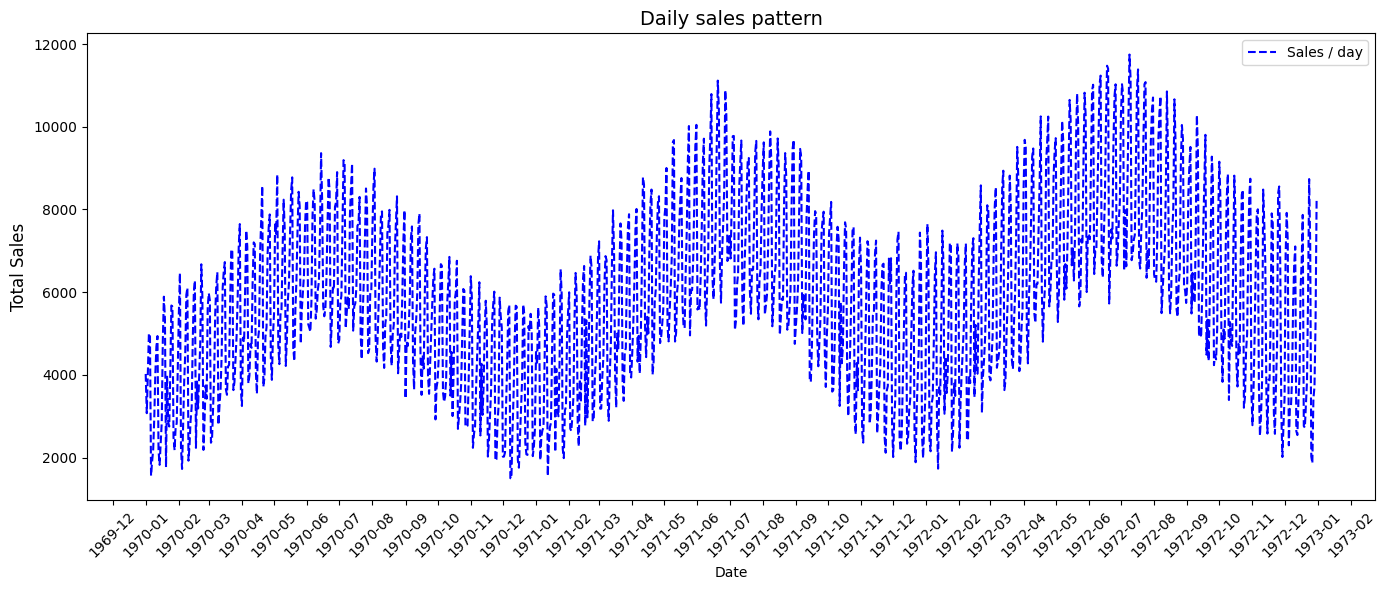

In [69]:
# Sales pattern analysis /day

import matplotlib.pyplot as plt

plt.figure(figsize = (14,6))
plt.plot(total_daily_sales['date'], total_daily_sales['total_sales'], linestyle = '--', color = 'blue', label = 'Sales / day')

plt.title('Daily sales pattern', fontsize = 14)
plt.xlabel('Date')
plt.ylabel('Total Sales', fontsize = 12)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Statistical summary of total sales per day
print(total_daily_sales.describe())

        total_sales
count   1096.000000
mean    5842.827053
std     2208.204434
min     1492.680000
25%     4135.432500
50%     5745.950000
75%     7406.320000
max    11746.770000


### Find out how sales fluctuate across different days of the week

In [73]:
# Collect day of week from date column

sales_items_resturants['date'] = pd.to_datetime(sales_items_resturants['date'])
sales_items_resturants['day_of_week'] = sales_items_resturants['date'].dt.day_name()

print(sales_items_resturants['day_of_week'].unique())

print()
sales_items_resturants[['date', 'day_of_week']].head(3)


['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday']



,date,day_of_week
0,2019-01-01,Tuesday
1,2019-01-01,Tuesday
2,2019-01-01,Tuesday


In [75]:
# Summarize sales with day of week

group_by_day = sales_items_resturants.groupby('day_of_week')
total_week_sales = group_by_day['total_sales'].sum()

total_week_sales_index = total_week_sales.reset_index()
print(total_week_sales.shape)

print()
total_week_sales = total_week_sales_index.copy()

print(total_week_sales.head())


(7,)

  day_of_week  total_sales
0      Friday   1257338.16
1      Monday    644799.97
2    Saturday   1250574.32
3      Sunday    630279.71
4    Thursday   1073534.52


In [77]:
# Put days in order.

order_of_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

total_week_sales['day_of_week'] = pd.Categorical(total_week_sales['day_of_week'], categories = order_of_days, ordered = True)
total_week_sales = total_week_sales.sort_values('day_of_week')

print(total_week_sales.head(7))

  day_of_week  total_sales
1      Monday    644799.97
5     Tuesday    734598.46
6   Wednesday    812613.31
4    Thursday   1073534.52
0      Friday   1257338.16
2    Saturday   1250574.32
3      Sunday    630279.71


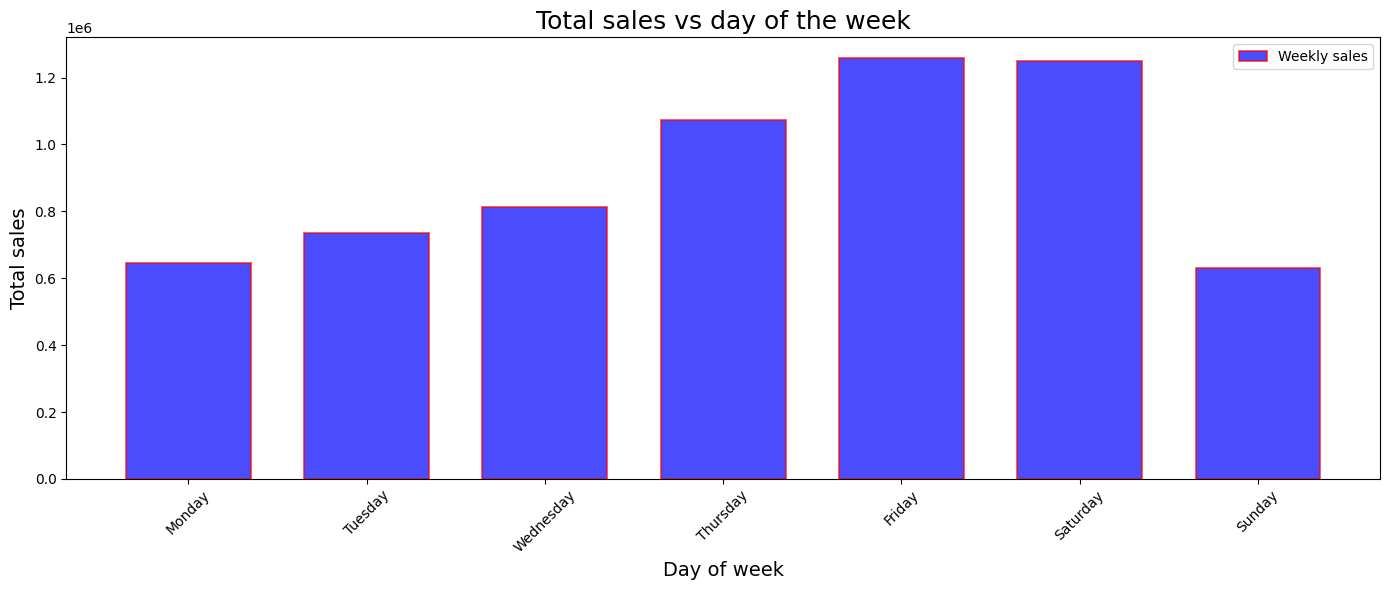

In [79]:
# plot: Sales with day

plt.figure(figsize = (14,6))

plt.bar(total_week_sales['day_of_week'], total_week_sales['total_sales'], color = 'blue',alpha = 0.7, edgecolor = 'red', width = 0.7,
        linewidth = 1.3, label = 'Weekly sales'
       )
plt.title('Total sales vs day of the week', fontsize = 18)
plt.xlabel('Day of week', fontsize = 14)
plt.ylabel('Total sales', fontsize = 14)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Look for any noticeable trends in the sales data for different months of the year

In [81]:
# Create month and year features to analyze monthly sales trends

sales_items_resturants['month'] = sales_items_resturants['date'].dt.month
print(sales_items_resturants['month'].unique())
print()

sales_items_resturants['year'] = sales_items_resturants['date'].dt.year
print(sales_items_resturants['year'].unique())

print()

sales_items_resturants[['date', 'month', 'year']].head()


[ 1  2  3  4  5  6  7  8  9 10 11 12]

[2019 2020 2021]



,date,month,year
0,2019-01-01,1,2019
1,2019-01-01,1,2019
2,2019-01-01,1,2019
3,2019-01-01,1,2019
4,2019-01-01,1,2019


In [83]:
# Aggregate Sales by Month (All Years Combined)


group_by_month = sales_items_resturants.groupby('month')
total_month_sales = group_by_month['total_sales'].sum()
total_month_sales_index = total_month_sales.reset_index()
print(total_month_sales_index.head(7))
print()
total_month_sales = total_month_sales_index.copy()
print(total_month_sales.shape)

print()

print(total_month_sales.head(7))

   month  total_sales
0      1    375778.02
1      2    394527.38
2      3    498218.89
3      4    571458.39
4      5    666063.17
5      6    691116.06
6      7    706038.79

(12, 2)

   month  total_sales
0      1    375778.02
1      2    394527.38
2      3    498218.89
3      4    571458.39
4      5    666063.17
5      6    691116.06
6      7    706038.79


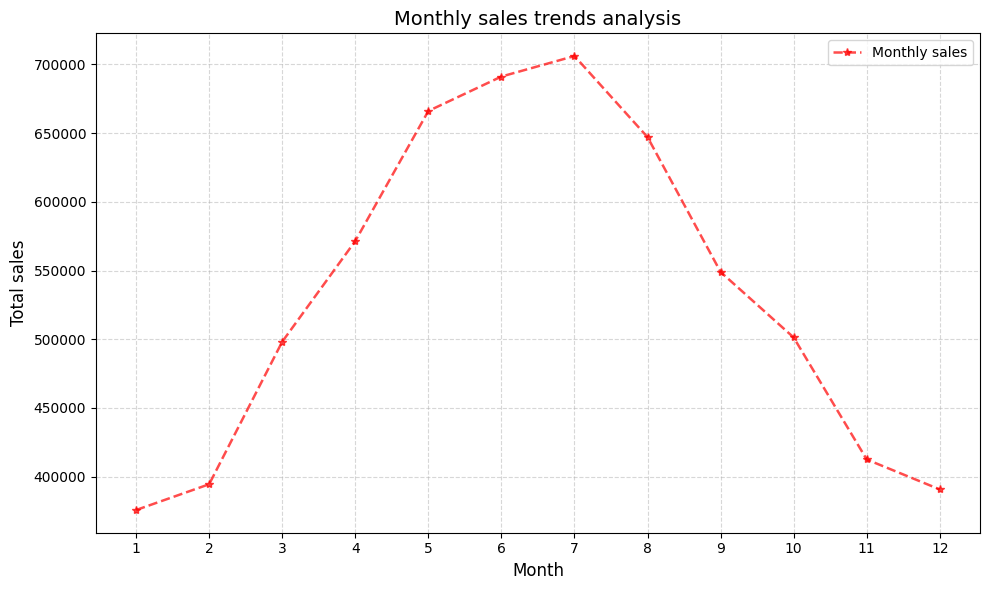

In [85]:
# Sales trends with month

plt.figure(figsize = (10,6))

plt.plot(total_month_sales['month'], total_month_sales['total_sales'], markersize = 6, linestyle = '--', marker = '*', linewidth = 1.8,
         alpha = 0.7, color = 'red', label = 'Monthly sales'
        )

plt.title('Monthly sales trends analysis', fontsize = 14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total sales', fontsize=12)

plt.xticks(range(1,13))
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

year  month
2019  1        109759.77
      2        114960.23
      3        151744.62
      4        165548.24
      5        201332.60
      6        202030.12
      7        202401.49
      8        192296.76
      9        157886.74
      10       141260.25
      11       123750.59
      12       108790.90
2020  1        121461.34
      2        134155.80
      3        160419.90
      4        185154.79
      5        218102.43
      6        232658.15
      7        229253.18
      8        219967.33
      9        188612.31
      10       173257.91
      11       138477.24
      12       132160.40
2021  1        144556.91
      2        145411.35
      3        186054.37
      4        220755.36
      5        246628.14
      6        256427.79
      7        274384.12
      8        234760.88
      9        202428.34
      10       186774.05
      11       150308.03
      12       149806.02
Name: total_sales, dtype: float64


<Figure size 1800x600 with 0 Axes>

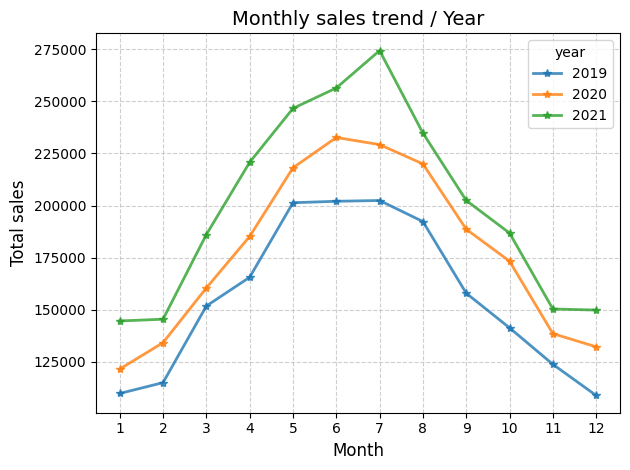

In [87]:
# Yearly sales trend analysis

group_by_year_month = sales_items_resturants.groupby(['year', 'month'])
#print(group_by_year_month.head(2))
year_month_sales = group_by_year_month['total_sales'].sum()
print(year_month_sales)

year_month_sales_index = year_month_sales.reset_index()
year_month_sales = year_month_sales_index.copy()
monthly_sales = year_month_sales.pivot(index = 'month', columns = 'year', values = 'total_sales')

plt.figure(figsize = (18,6))
monthly_sales.plot(marker = '*', linewidth = 2, alpha = 0.8)
plt.title('Monthly sales trend / Year', fontsize = 14)
plt.xlabel('Month', fontsize = 12)
plt.ylabel('Total sales', fontsize = 12)
plt.xticks(range(1,13))
plt.grid(True, linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

###  Examine the sales distribution across different quarters averaged over the years. Identify any  noticeable patterns. 

In [89]:
# Generate quarter feature from date column 
sales_items_resturants['quarter'] = sales_items_resturants['date'].dt.quarter

In [91]:
# Sales via Quarter

group_by_quarter = sales_items_resturants.groupby('quarter')
total_quarter_sales = group_by_quarter['total_sales'].sum()
total_quarter_sales_index = total_quarter_sales.reset_index()
total_quarter_sales = total_quarter_sales_index.copy()
print(total_quarter_sales.shape)
print()
print(total_quarter_sales.head())

(4, 2)

   quarter  total_sales
0        1   1268524.29
1        2   1928637.62
2        3   1901991.15
3        4   1304585.39


#### Sales distribution across different quarters

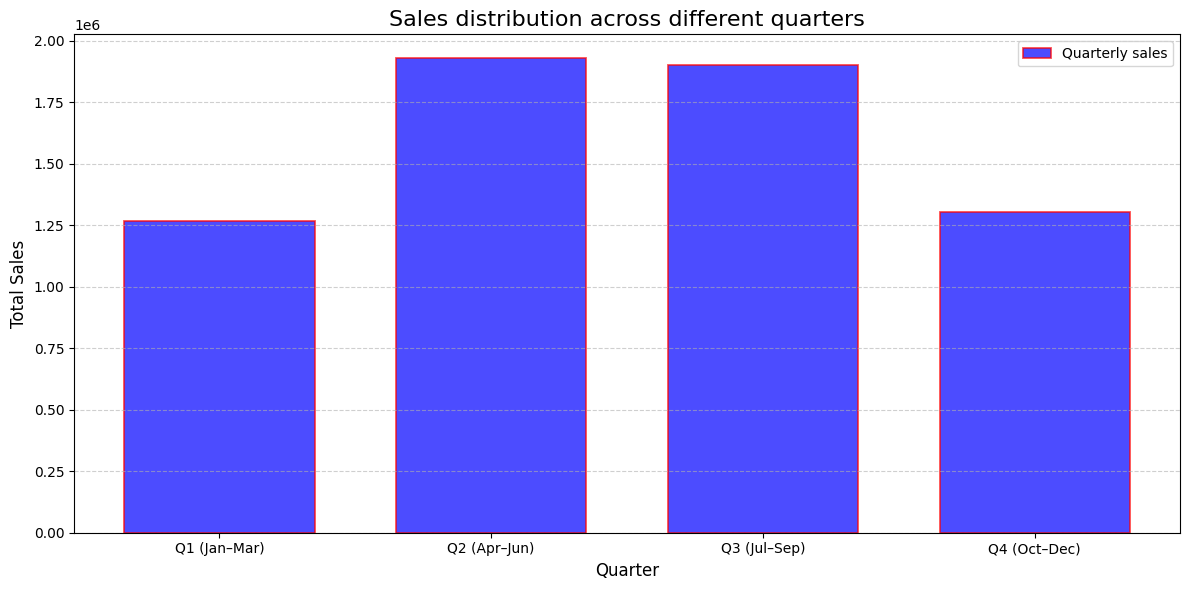

In [93]:
plt.figure(figsize = (12,6))

plt.bar(total_quarter_sales['quarter'], total_quarter_sales['total_sales'], alpha = 0.7, color = 'blue', edgecolor = 'red', linewidth = 1.3,
        width = 0.7, label = 'Quarterly sales'
       )

plt.title('Sales distribution across different quarters', fontsize = 16)
plt.xlabel('Quarter', fontsize = 12)
plt.ylabel('Total Sales', fontsize = 12)
plt.xticks([1,2,3,4], ['Q1 (Jan–Mar)', 'Q2 (Apr–Jun)', 'Q3 (Jul–Sep)', 'Q4 (Oct–Dec)'])
plt.legend()
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

#### Quarterly sales trends via Year

In [97]:
# Quarterly sales trends via Year

group_by_year_quarter = sales_items_resturants.groupby(['year', 'quarter'])
quarter_sales_year = group_by_year_quarter['total_sales'].sum()
quarter_sales_year_index = quarter_sales_year .reset_index()
quarter_sales_year = quarter_sales_year_index.copy()
print(quarter_sales_year.shape)
print()
print(quarter_sales_year.head(12))

(12, 3)

    year  quarter  total_sales
0   2019        1    376464.62
1   2019        2    568910.96
2   2019        3    552584.99
3   2019        4    373801.74
4   2020        1    416037.04
5   2020        2    635915.37
6   2020        3    637832.82
7   2020        4    443895.55
8   2021        1    476022.63
9   2021        2    723811.29
10  2021        3    711573.34
11  2021        4    486888.10


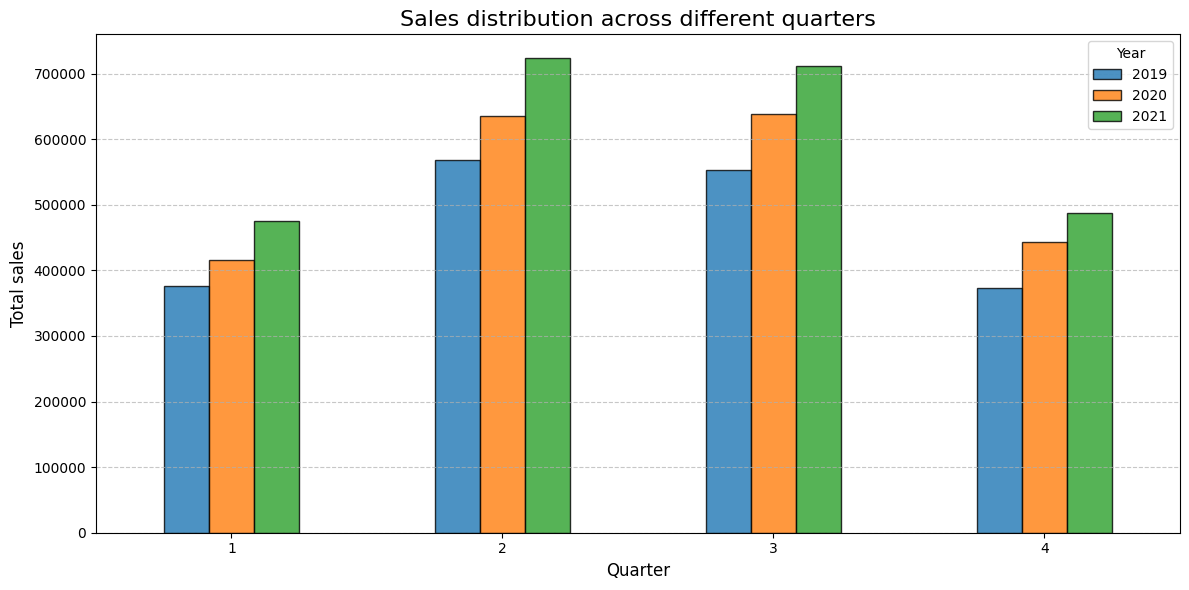

In [99]:
quarterly_sales = quarter_sales_year.pivot(index = 'quarter', columns = 'year', values = 'total_sales')
quarterly_sales.plot(kind = 'bar', figsize = (12,6), alpha = 0.8, edgecolor = 'black')

plt.title('Sales distribution across different quarters', fontsize=16)
plt.xlabel('Quarter', fontsize = 12)
plt.ylabel('Total sales', fontsize = 12)
plt.xticks(rotation = 0)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.legend(title = 'Year')
plt.tight_layout()
plt.show()

###  Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days. 


In [101]:
# Use total sales to compare restaurant performance

group_by_restaurant = sales_items_resturants.groupby('store_name')
total_restaurant_sales = group_by_restaurant['total_sales'].sum()
total_restaurant_sales_index = total_restaurant_sales.reset_index()
total_restaurant_sales = total_restaurant_sales_index.copy()

# Find out which restaurant had the most sales 
total_restaurant_sales = total_restaurant_sales.sort_values(by = 'total_sales', ascending = False)

print(total_restaurant_sales.shape)
print()
print(total_restaurant_sales.head())

(6, 2)

       store_name  total_sales
1     Bob's Diner   6337275.69
3        Fou Cher     27885.37
2     Corner Cafe     16551.43
4        Surfs Up     15651.49
0  Beachfront Bar      3796.20


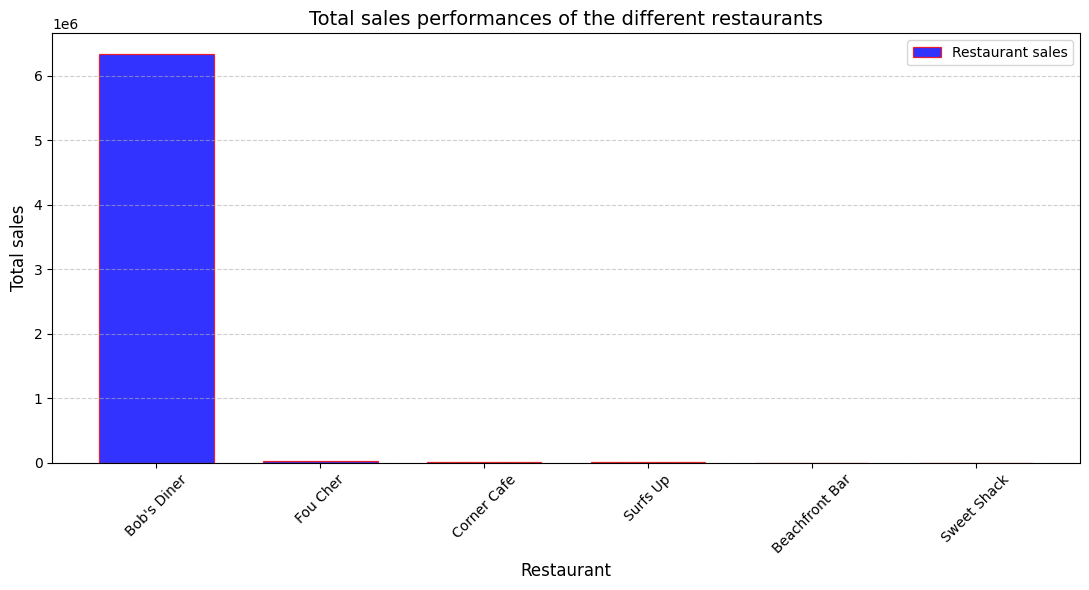

In [103]:
# Plot for restaurant performance

plt.figure(figsize = (11,6))

plt.bar(total_restaurant_sales['store_name'], total_restaurant_sales['total_sales'], alpha = 0.8, color = 'blue', linewidth = 0.9, edgecolor = 'red',
        width = 0.7, label = 'Restaurant sales'
)
plt.title('Total sales performances of the different restaurants', fontsize = 14)
plt.xlabel('Restaurant', fontsize=12)
plt.ylabel('Total sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis = 'y', linestyle = '--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Sales for each restaurant across different years, months, and days.

#### Analyze Sales via Year for each Restaurant

In [105]:
# Total yearly sales each restaurant

group_by_restaurant_year = sales_items_resturants.groupby(['store_name', 'year'])
yearly_restaurant_sales = group_by_restaurant_year['total_sales'].sum()
yearly_restaurant_sales_index = yearly_restaurant_sales.reset_index()
total_yearly_sales_each_restaurant = yearly_restaurant_sales_index.copy()

print(total_yearly_sales_each_restaurant.shape)
print()
print(total_yearly_sales_each_restaurant.head())

(18, 3)

       store_name  year  total_sales
0  Beachfront Bar  2019      1281.85
1  Beachfront Bar  2020      1267.21
2  Beachfront Bar  2021      1247.14
3     Bob's Diner  2019   1849483.49
4     Bob's Diner  2020   2112331.91


In [107]:
# year restaurant pivot data
year_restaurant_pivot_data_for_plot = total_yearly_sales_each_restaurant.pivot(index = 'year', columns = 'store_name', values = 'total_sales')

print(year_restaurant_pivot_data_for_plot.shape)
print()
print(year_restaurant_pivot_data_for_plot.head())

(3, 6)

store_name  Beachfront Bar  Bob's Diner  Corner Cafe  Fou Cher  Surfs Up  \
year                                                                       
2019               1281.85   1849483.49      5292.93   9698.80   5132.65   
2020               1267.21   2112331.91      5347.71   8590.87   5314.43   
2021               1247.14   2375460.29      5910.79   9595.70   5204.41   

store_name  Sweet Shack  
year                     
2019             872.59  
2020             828.65  
2021             877.03  


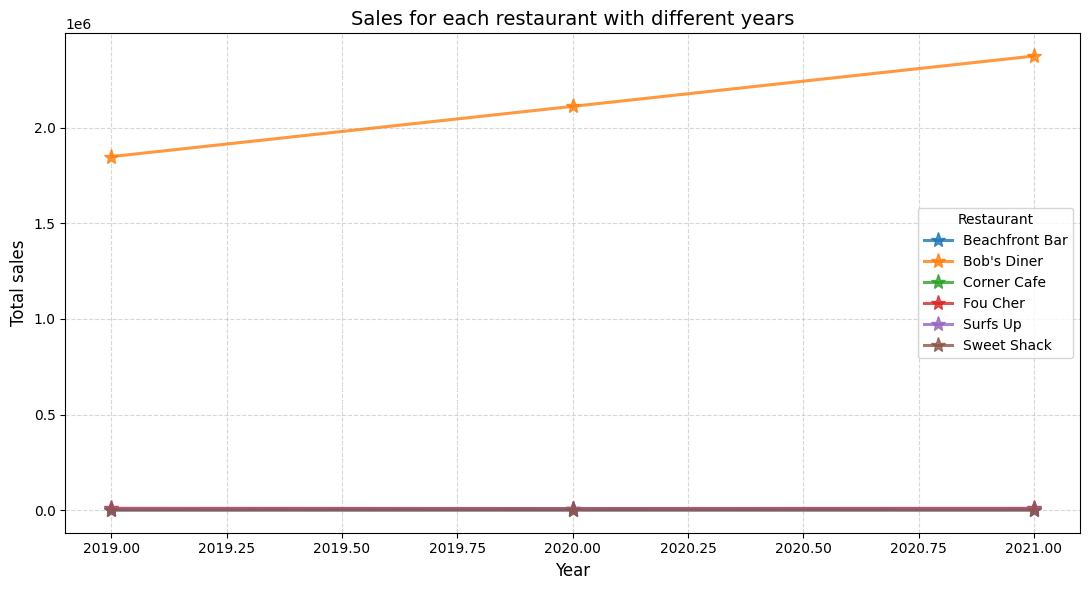

In [109]:
# plot for sales via Year with each restaurant
year_restaurant_pivot_data_for_plot.plot(figsize = (11,6), alpha = 0.8, marker = '*', markersize = 11, linewidth = 2.2)

plt.title('Sales for each restaurant with different years', fontsize = 14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total sales', fontsize=12)

plt.grid(True, linestyle='--', alpha = 0.5)
plt.legend(title = 'Restaurant')
plt.tight_layout()
plt.show()

#### Analyze Sales via month for each Restaurant

In [111]:
# Total monthly sales each restaurant

group_by_restaurant_month = sales_items_resturants.groupby(['store_name', 'month'])
monthly_restaurant_sales = group_by_restaurant_month['total_sales'].sum()
monthly_restaurant_sales_index = monthly_restaurant_sales.reset_index()
total_monthly_sales_each_restaurant = monthly_restaurant_sales_index.copy()

print(total_monthly_sales_each_restaurant .shape)
print()
print(total_monthly_sales_each_restaurant .head())

(72, 3)

       store_name  month  total_sales
0  Beachfront Bar      1       315.55
1  Beachfront Bar      2       318.10
2  Beachfront Bar      3       340.23
3  Beachfront Bar      4       317.58
4  Beachfront Bar      5       332.64


In [113]:
# month restaurant pivot data
month_restaurant_pivot_data_for_plot = total_monthly_sales_each_restaurant.pivot(index = 'month', columns = 'store_name', 
                                                                                 values='total_sales')

print(month_restaurant_pivot_data_for_plot .shape)
print()
print(month_restaurant_pivot_data_for_plot .head())

(12, 6)

store_name  Beachfront Bar  Bob's Diner  Corner Cafe  Fou Cher  Surfs Up  \
month                                                                      
1                   315.55    370097.57      1055.98   2843.70   1210.82   
2                   318.10    389551.18      1241.46   1697.06   1537.97   
3                   340.23    492825.83      1335.54   2417.40   1083.98   
4                   317.58    565964.33      1394.36   2342.80   1247.49   
5                   332.64    659818.97      1370.26   2782.85   1523.98   

store_name  Sweet Shack  
month                    
1                254.40  
2                181.61  
3                215.91  
4                191.83  
5                234.47  


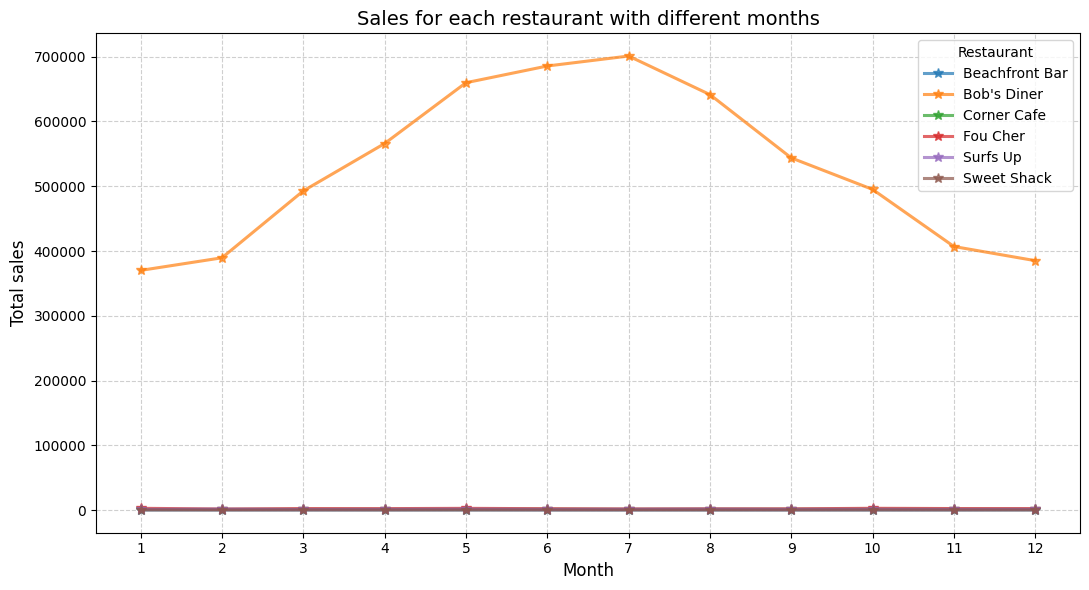

In [115]:
# plot for sales via month with each restaurant

month_restaurant_pivot_data_for_plot.plot(figsize = (11,6), marker = '*', markersize = 7, linewidth = 2.2, alpha = 0.7)

plt.title('Sales for each restaurant with different months', fontsize = 14)
plt.xlabel('Month', fontsize = 12)
plt.ylabel('Total sales', fontsize = 12)
plt.xticks(range(1,13))
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.legend(title = 'Restaurant')
plt.tight_layout()
plt.show()

#### Analyze sales via day for each Restaurant

In [121]:
# Total daily sales each restaurant

group_by_restaurant_day = sales_items_resturants.groupby(['store_name', 'day_of_week'])
day_of_week_restaurant_sales = group_by_restaurant_day['total_sales'].sum()
day_of_week_restaurant_sales_index = day_of_week_restaurant_sales.reset_index()
total_day_of_week_restaurant_sales = day_of_week_restaurant_sales_index.copy()

print(total_day_of_week_restaurant_sales.shape)
print()
print(total_day_of_week_restaurant_sales.head(15))

(42, 3)

        store_name day_of_week  total_sales
0   Beachfront Bar      Friday       508.79
1   Beachfront Bar      Monday       544.78
2   Beachfront Bar    Saturday       538.93
3   Beachfront Bar      Sunday       523.11
4   Beachfront Bar    Thursday       518.58
5   Beachfront Bar     Tuesday       548.72
6   Beachfront Bar   Wednesday       613.29
7      Bob's Diner      Friday   1247393.16
8      Bob's Diner      Monday    635165.98
9      Bob's Diner    Saturday   1241421.51
10     Bob's Diner      Sunday    621069.50
11     Bob's Diner    Thursday   1063813.76
12     Bob's Diner     Tuesday    725443.80
13     Bob's Diner   Wednesday    802967.98
14     Corner Cafe      Friday      2460.83


In [123]:

monday_to_sunday = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
total_day_of_week_restaurant_sales['day_of_week'] = pd.Categorical(total_day_of_week_restaurant_sales['day_of_week'],
                                                                   categories = monday_to_sunday,
                                                                   ordered = True
                                                                  )
total_day_of_week_restaurant_sales = total_day_of_week_restaurant_sales.sort_values('day_of_week')

In [125]:
# day restaurant pivot data

day_restaurant_pivot_data_for_plot = total_day_of_week_restaurant_sales.pivot(index = 'day_of_week', columns = 'store_name', 
                                                     values = 'total_sales')
print(day_restaurant_pivot_data_for_plot.shape)
print()
print(day_restaurant_pivot_data_for_plot.head())

(7, 6)

store_name   Beachfront Bar  Bob's Diner  Corner Cafe  Fou Cher  Surfs Up  \
day_of_week                                                                 
Monday               544.78    635165.98      2395.01   3927.47   2402.87   
Tuesday              548.72    725443.80      2487.38   3742.68   1970.81   
Wednesday            613.29    802967.98      2121.01   4342.13   2232.88   
Thursday             518.58   1063813.76      2343.02   4272.16   2233.90   
Friday               508.79   1247393.16      2460.83   4227.35   2399.53   

store_name   Sweet Shack  
day_of_week               
Monday            363.86  
Tuesday           405.07  
Wednesday         336.02  
Thursday          353.10  
Friday            348.50  


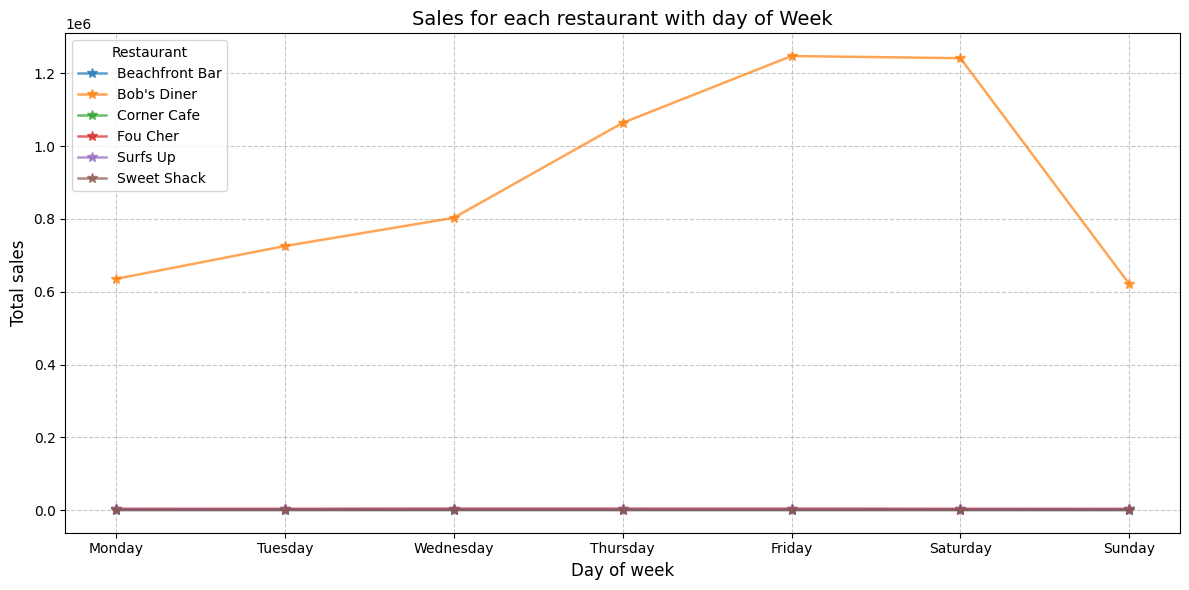

In [127]:
# plot for sales via day with each restaurant

day_restaurant_pivot_data_for_plot.plot(figsize = (12,6), alpha = 0.7, markersize = 7,  marker = '*', linewidth = 1.8)

plt.title('Sales for each restaurant with day of Week', fontsize = 14)
plt.xlabel('Day of week', fontsize = 12)
plt.ylabel('Total sales', fontsize = 12)
plt.grid(True, alpha = 0.7, linestyle = '--')
plt.legend(title = 'Restaurant')
plt.tight_layout()
plt.show()

### Identify the most popular items overall and the stores where they are being sold. Also, find  out the most popular item at each store 

In [129]:
# Identify the most popular items overall 

group_by_item = sales_items_resturants.groupby('item_name')
group_by_item_popularity = group_by_item['item_count'].sum()
group_by_item_popularity_index = group_by_item_popularity.reset_index()
group_by_item_popularity = group_by_item_popularity_index.copy()
group_by_item_popularity = group_by_item_popularity.sort_values(by = 'item_count', ascending = False)

print('Top 12 most popular items overall:')
print()
print(group_by_item_popularity.head(12))

Top 12 most popular items overall:

                            item_name  item_count
85                 Strawberry Smoothy      236337
46               Frozen Milky Smoothy      103263
9                  Amazing pork lunch       61043
64                      Mutton Dinner       52772
67                       Orange Juice       43874
22            Blue Ribbon Beef Entree       42774
4     Amazing Steak Dinner with Rolls       34439
88            Sweet Frozen Soft Drink       27490
83    Sea Bass with Vegetables Dinner       23839
90                    Sweet Lamb Cake       18764
1   Amazing Fish with Vegetables Meal       13190
41               Fantastic Sweet Cola        7791


In [131]:
# Identify stores where top items are sold

group_by_item_name_store_name = sales_items_resturants.groupby(['item_name', 'store_name'])
total_quantity_item_store_sales = group_by_item_name_store_name['item_count'].sum()
total_quantity_item_store_sales_index = total_quantity_item_store_sales.reset_index()
total_quantity_item_store_sales = total_quantity_item_store_sales_index.copy()

print(total_quantity_item_store_sales.shape)
print()
print(total_quantity_item_store_sales.head())

(100, 3)

                           item_name   store_name  item_count
0                   Amazing Cocktail     Surfs Up          91
1  Amazing Fish with Vegetables Meal  Bob's Diner       13190
2          Amazing Frozen Milky Cake  Bob's Diner         211
3                Amazing Lamb Dinner     Fou Cher          52
4    Amazing Steak Dinner with Rolls  Bob's Diner       34439


In [133]:
# Find top 12 most popular items

top_12_most_popular_items = group_by_item_popularity.head(12)['item_name']
top_items_stores = total_quantity_item_store_sales [total_quantity_item_store_sales['item_name'].isin(top_12_most_popular_items)]

top_items_stores = top_items_stores.sort_values(by = ['item_name', 'item_count'], 
                                                ascending = [True, False]
                                               )

print('Top 12 items and stores Where they are being Sold:')
print()
print(top_items_stores)

Top 12 items and stores Where they are being Sold:

                            item_name   store_name  item_count
1   Amazing Fish with Vegetables Meal  Bob's Diner       13190
4     Amazing Steak Dinner with Rolls  Bob's Diner       34439
9                  Amazing pork lunch  Bob's Diner       61043
22            Blue Ribbon Beef Entree  Bob's Diner       42774
42               Fantastic Sweet Cola  Bob's Diner        7791
47               Frozen Milky Smoothy  Bob's Diner      102990
48               Frozen Milky Smoothy  Corner Cafe         273
68                      Mutton Dinner  Bob's Diner       52772
71                       Orange Juice  Bob's Diner       43874
89    Sea Bass with Vegetables Dinner  Bob's Diner       23839
91                 Strawberry Smoothy  Bob's Diner      236337
94            Sweet Frozen Soft Drink  Bob's Diner       27490
96                    Sweet Lamb Cake  Bob's Diner       18764


In [135]:
#  find out the most popular item at each store
group_by_store_name_item_name = sales_items_resturants.groupby(['store_name', 'item_name'])
total_quantity_store_item_sales = group_by_store_name_item_name['item_count'].sum()
total_quantity_store_item_sales_index = total_quantity_store_item_sales.reset_index()
total_quantity_store_item_sales = total_quantity_store_item_sales_index.copy()

print(total_quantity_store_item_sales.shape)
print()
print(total_quantity_store_item_sales.head())

(100, 3)

       store_name                        item_name  item_count
0  Beachfront Bar           Awesome Vodka Cocktail          12
1  Beachfront Bar          Fantastic Milky Smoothy        1147
2  Beachfront Bar          Original Crazy Cocktail         106
3  Beachfront Bar            Original Gin Cocktail          21
4  Beachfront Bar  Original Sweet Milky Soft Drink           0


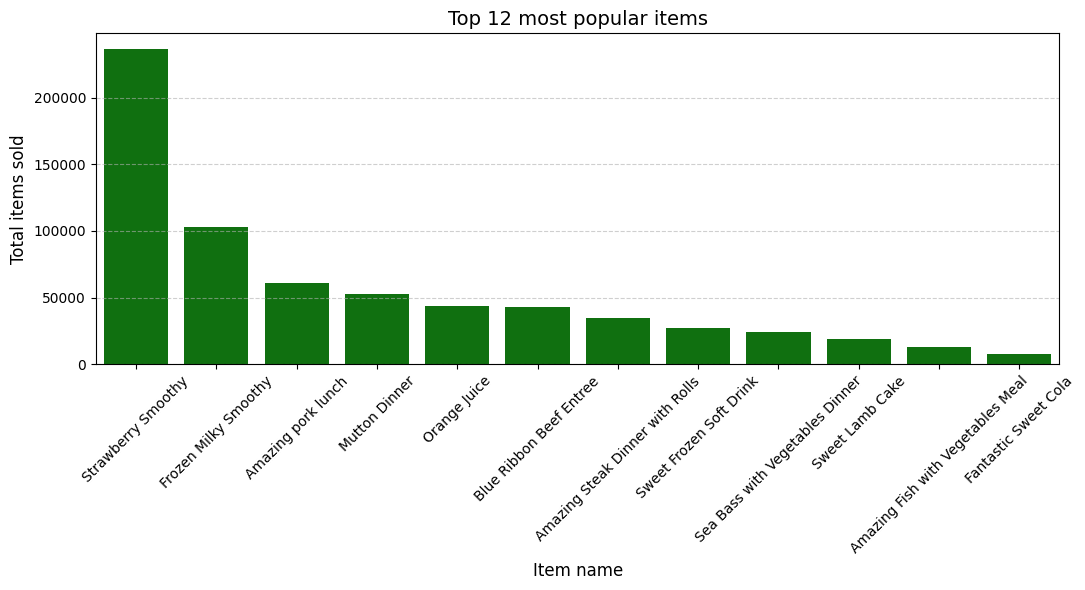

In [137]:
# Plot top 12 most popular items
import seaborn as sns

plt.figure(figsize = (11,6))

sns.barplot(data = group_by_item_popularity.head(12), x = 'item_name', y = 'item_count',
            color = 'green'
           )

plt.title('Top 12 most popular items', fontsize = 14)
plt.xlabel('Item name', fontsize=12)
plt.ylabel('Total items sold', fontsize = 12)
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

### Determine if the store with the highest sales volume is also making the most money per day

In [139]:
# Calculate Total Sales Volume per Store (Based on Item Quantity Sold)

group_by_store_name = sales_items_resturants.groupby('store_name')
store_items_sales_volume = group_by_store_name['item_count'].sum()
store_items_sales_volume_index = store_items_sales_volume.reset_index()
store_items_sales_volume = store_items_sales_volume_index.copy()
store_items_sales_volume = store_items_sales_volume.sort_values(by = 'item_count', ascending = False)

print('At each store, total items sales volume:')
print()
print(store_items_sales_volume)

At each store, total items sales volume:

       store_name  item_count
1     Bob's Diner      687527
4        Surfs Up        1803
5     Sweet Shack        1736
2     Corner Cafe        1310
0  Beachfront Bar        1305
3        Fou Cher        1106


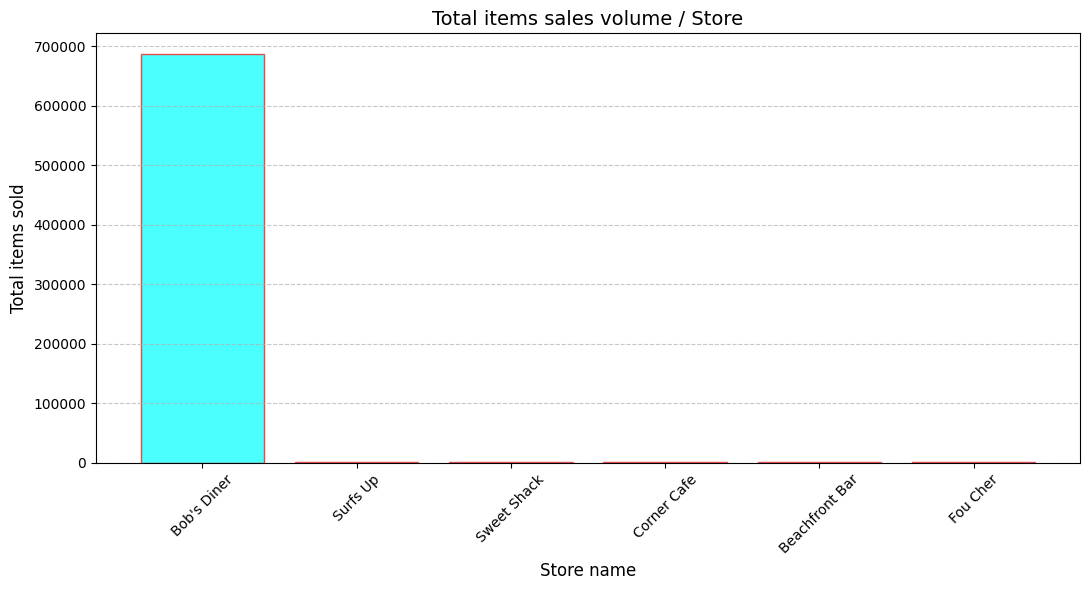

In [141]:
plt.figure(figsize = (11,6))

plt.bar(store_items_sales_volume['store_name'], store_items_sales_volume['item_count'], color = 'cyan', alpha = 0.7,
        edgecolor = 'red'
       )

plt.title('Total items sales volume / Store', fontsize = 14)
plt.xlabel('Store name', fontsize = 12)
plt.ylabel('Total items sold', fontsize = 12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [143]:
# Find total revenue in each store

# revenue: a new column
sales_items_resturants['revenue'] = sales_items_resturants['price'] * sales_items_resturants['item_count']
group_by_store_name_revenue = sales_items_resturants.groupby('store_name')
total_store_revenue = group_by_store_name_revenue['revenue'].sum()
total_store_revenue_index = total_store_revenue.reset_index()
total_store_revenue = total_store_revenue_index.copy()
total_store_revenue = total_store_revenue.sort_values(by = 'revenue', ascending = False)

print("Total Revenue / Store:")
print()
print(total_store_revenue)

Total Revenue / Store:

       store_name     revenue
1     Bob's Diner  6337275.69
3        Fou Cher    27885.37
2     Corner Cafe    16551.43
4        Surfs Up    15651.49
0  Beachfront Bar     3796.20
5     Sweet Shack     2578.27


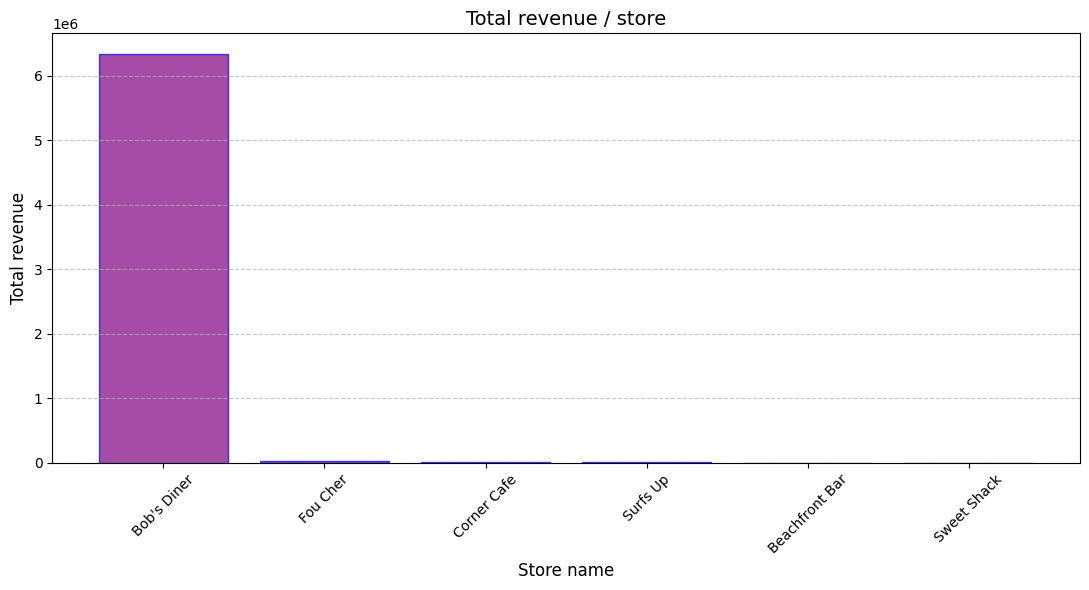

In [145]:
plt.figure(figsize=(11,6))

plt.bar(total_store_revenue['store_name'], total_store_revenue['revenue'], color = 'purple', alpha = 0.7, edgecolor = 'blue')
plt.title('Total revenue / store', fontsize = 14)
plt.xlabel('Store name', fontsize = 12)
plt.ylabel('Total revenue', fontsize = 12)
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [149]:
# Find daily revenue in each store

# Group data by store name and date
group_by_store_name_date = sales_items_resturants.groupby(['store_name', 'date'])
total_revenue_each_store_day = group_by_store_name_date['revenue'].sum()
total_revenue_each_store_day_index = total_revenue_each_store_day.reset_index()
total_revenue_each_store_day = total_revenue_each_store_day_index.copy()

print(total_revenue_each_store_day.shape)
print()
print(total_revenue_each_store_day.head())

(6576, 3)

       store_name       date  revenue
0  Beachfront Bar 2019-01-01     2.91
1  Beachfront Bar 2019-01-02     2.91
2  Beachfront Bar 2019-01-03     2.91
3  Beachfront Bar 2019-01-04     5.34
4  Beachfront Bar 2019-01-05     2.91


In [151]:
# Find average revenue / day with each store

group_by_store_name_average_revenue = total_revenue_each_store_day.groupby('store_name')
average_revenue_each_day_each_store = group_by_store_name_average_revenue['revenue'].mean()
average_revenue_each_day_each_store_index = average_revenue_each_day_each_store.reset_index()
average_revenue_each_day_each_store = average_revenue_each_day_each_store_index.copy()
average_revenue_each_day_each_store = average_revenue_each_day_each_store.sort_values(by = 'revenue', ascending = False)

print('average revenue / day with each stor:')
print()
print(average_revenue_each_day_each_store)

average revenue / day with each stor:

       store_name      revenue
1     Bob's Diner  5782.185849
3        Fou Cher    25.442856
2     Corner Cafe    15.101670
4        Surfs Up    14.280557
0  Beachfront Bar     3.463686
5     Sweet Shack     2.352436


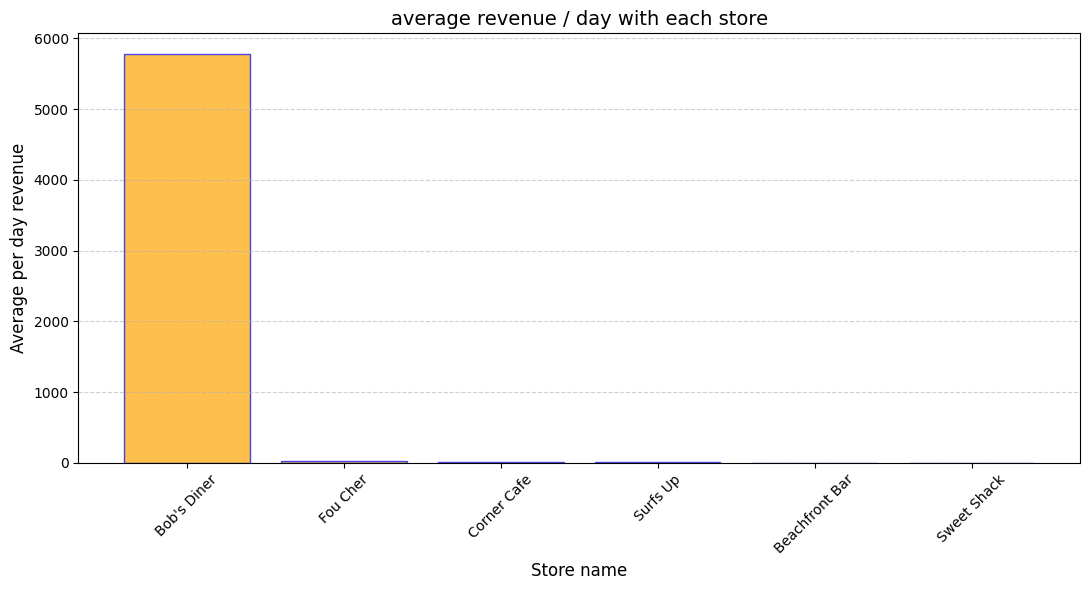

In [153]:
# average revenue / day with each store

plt.figure(figsize = (11,6))

plt.bar(average_revenue_each_day_each_store['store_name'], average_revenue_each_day_each_store['revenue'], color = 'orange', alpha = 0.7,
        edgecolor = 'blue'
       )

plt.title('average revenue / day with each store', fontsize = 14)
plt.xlabel('Store name', fontsize = 12)
plt.ylabel('Average per day revenue', fontsize = 12)
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

In [155]:
# Merge store volume with average daily revenue
group_by_store_name = sales_items_resturants.groupby('store_name')
total_items_sold_each_store  = group_by_store_name['item_count'].sum().reset_index()
merge_to_compare = total_items_sold_each_store.merge(average_revenue_each_day_each_store, on = 'store_name')

# Rename columns if needed
merge_to_compare = merge_to_compare.rename(columns={'item_count': 'total_items_sold',
                                                    'revenue': 'average_revenue_each_day'
                                                   })
merge_to_compare = merge_to_compare.sort_values(by = 'total_items_sold', ascending=False)


print(' Total items sold each store vs average revenue each day:')
print()
print(merge_to_compare)

 Total items sold each store vs average revenue each day:

       store_name  total_items_sold  average_revenue_each_day
1     Bob's Diner            687527               5782.185849
4        Surfs Up              1803                 14.280557
5     Sweet Shack              1736                  2.352436
2     Corner Cafe              1310                 15.101670
0  Beachfront Bar              1305                  3.463686
3        Fou Cher              1106                 25.442856


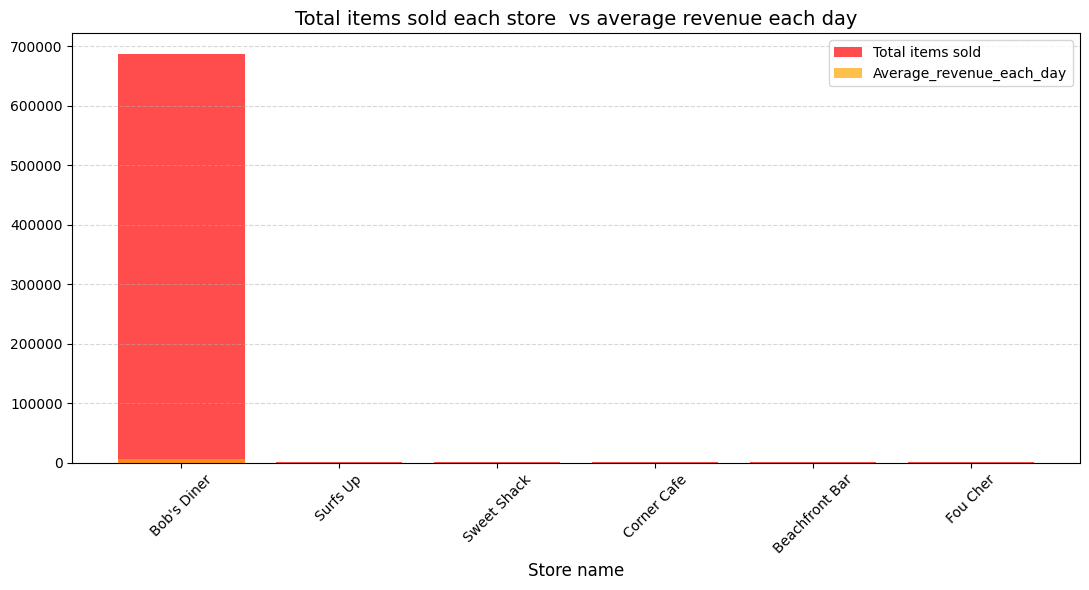

In [157]:
plt.figure(figsize = (11,6))

plt.bar(merge_to_compare['store_name'], merge_to_compare['total_items_sold'], alpha = 0.7, label = 'Total items sold', color = 'red'
)

plt.bar(merge_to_compare['store_name'], merge_to_compare['average_revenue_each_day'], alpha = 0.7, label = 'Average_revenue_each_day',
        color = 'orange')

plt.title('Total items sold each store  vs average revenue each day', fontsize = 14)
plt.xlabel('Store name', fontsize = 12)
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
plt.show()

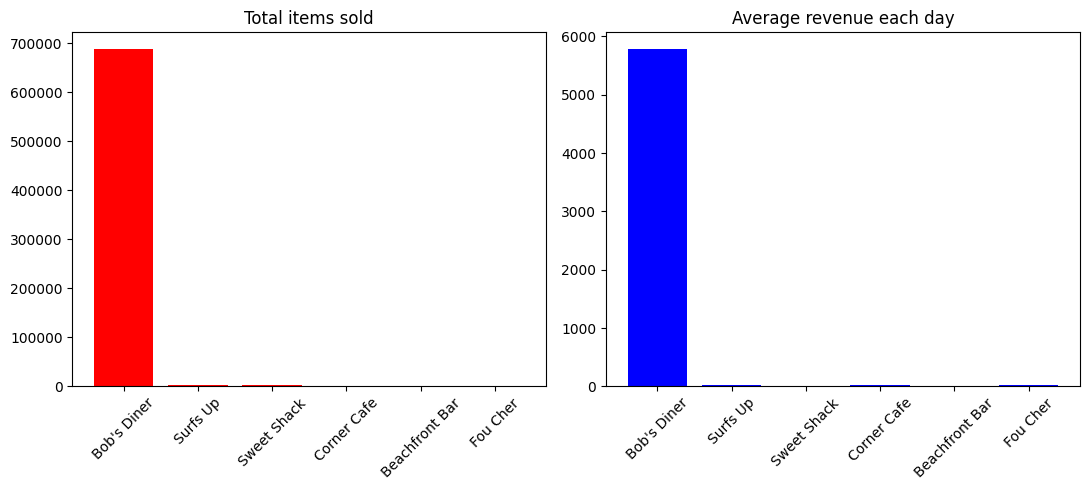

In [159]:
plt.figure(figsize=(11,5))

# Items Sold
plt.subplot(1,2,1)
plt.bar(merge_to_compare['store_name'], merge_to_compare['total_items_sold'], color = 'red')
plt.title('Total items sold')
plt.xticks(rotation = 45)

#  Average revenue each day
plt.subplot(1,2,2)
plt.bar(merge_to_compare['store_name'], merge_to_compare['average_revenue_each_day'], color = 'blue')
plt.title('Average revenue each day')
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

###  Identify the most expensive item at each restaurant and find out its calorie count

In [161]:
# Identify Most Expensive Item at Each Store


group_by_store_name = sales_items_resturants.groupby('store_name')
# Most expensive item index in each store
group_by_store_name_most_expensive_idx = group_by_store_name['cost'].idxmax()

most_expensive_items = sales_items_resturants.loc[group_by_store_name_most_expensive_idx, ['store_name', 'item_name', 'cost', 'kcal']]
most_expensive_items = most_expensive_items.sort_values(by = 'store_name')

print("Most expensive item at each store:")
print()
print(most_expensive_items)

Most expensive item at each store:

        store_name                      item_name   cost  kcal
68  Beachfront Bar          Sweet Vegi Soft Drink   5.70   538
0      Bob's Diner              Sweet Fruity Cake  29.22   931
58     Corner Cafe                     Pike Lunch  26.37   653
82        Fou Cher  Blue Ribbon Fruity Vegi Lunch  53.98   881
8         Surfs Up                     Steak Meal  26.21   607
79     Sweet Shack  Blue Ribbon Frozen Milky Cake   7.70   636


In [229]:
most_expensive_items = most_expensive_items.sort_values(by = 'cost', ascending = False)
print(most_expensive_items)

        store_name                      item_name   cost  kcal
82        Fou Cher  Blue Ribbon Fruity Vegi Lunch  53.98   881
0      Bob's Diner              Sweet Fruity Cake  29.22   931
58     Corner Cafe                     Pike Lunch  26.37   653
8         Surfs Up                     Steak Meal  26.21   607
79     Sweet Shack  Blue Ribbon Frozen Milky Cake   7.70   636
68  Beachfront Bar          Sweet Vegi Soft Drink   5.70   538


## Forecasting using machine learning algorithms

In [163]:
# Find Sales Data per day

# Make revenue column
sales_items_resturants['revenue'] = sales_items_resturants['price'] * sales_items_resturants['item_count']

group_by_date = sales_items_resturants.groupby('date')
total_sales_per_day = group_by_date['revenue'].sum()
total_sales_per_day_index = total_sales_per_day.reset_index()
total_sales_per_day = total_sales_per_day_index.copy()
total_sales_per_day = total_sales_per_day.sort_values(by = 'date')

print(total_sales_per_day.shape)
print()
print(total_sales_per_day.head())

(1096, 2)

        date  revenue
0 2019-01-01  4023.00
1 2019-01-02  3074.69
2 2019-01-03  4062.71
3 2019-01-04  5006.81
4 2019-01-05  4927.53


In [165]:
# Create features from date 

# Organize columns: date,  revenue,  year,  month,  day_of_month,  day_of_week,  quarter

total_sales_per_day['date'] = pd.to_datetime(total_sales_per_day['date'])
total_sales_per_day['year'] = total_sales_per_day['date'].dt.year
total_sales_per_day['month'] = total_sales_per_day['date'].dt.month
total_sales_per_day['day_of_month'] = total_sales_per_day['date'].dt.day
total_sales_per_day['day_of_week'] = total_sales_per_day['date'].dt.dayofweek
total_sales_per_day['quarter'] = total_sales_per_day['date'].dt.quarter

print(total_sales_per_day.shape)
print()
print(total_sales_per_day.head(8))

(1096, 7)

        date  revenue  year  month  day_of_month  day_of_week  quarter
0 2019-01-01  4023.00  2019      1             1            1        1
1 2019-01-02  3074.69  2019      1             2            2        1
2 2019-01-03  4062.71  2019      1             3            3        1
3 2019-01-04  5006.81  2019      1             4            4        1
4 2019-01-05  4927.53  2019      1             5            5        1
5 2019-01-06  1563.67  2019      1             6            6        1
6 2019-01-07  1907.48  2019      1             7            0        1
7 2019-01-08  2192.53  2019      1             8            1        1


### Use the data from the last six months as the testing data 

In [ ]:
'

In [167]:
# Split dataset into training and testing datasets for model forecasting

# Find a split date where the last 6 months will be used for model testing
split_date_last_6_months = total_sales_per_day['date'].max() - pd.DateOffset(months=6)

train_dataset = total_sales_per_day[total_sales_per_day['date'] <= split_date_last_6_months]
test_dataset = total_sales_per_day[total_sales_per_day['date'] > split_date_last_6_months]

# Set feature columns for train and test_datasets
train_test_datasets_feature_columns = ['year', 'month', 'day_of_month', 'day_of_week', 'quarter']

target_column = 'revenue'

X_train = train_dataset[train_test_datasets_feature_columns]
y_train = train_dataset[target_column]
X_test = test_dataset[train_test_datasets_feature_columns]
y_test = test_dataset[target_column]

print('Training dataset shape:', X_train.shape, y_train.shape)
print('Testing dataset shape:', X_test.shape, y_test.shape)

Training dataset shape: (912, 5) (912,)
Testing dataset shape: (184, 5) (184,)


### Compute the root mean square error (RMSE) values for each model to compare their performances 

#### Use Linear Regression Model for training and testing

In [169]:
# Use Linear Regression Model for training and testing
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

y_predicted_on_test_data_linear_regression_model = linear_regression_model.predict(X_test)
roort_mean_squared_error_test_data_linear_regression_model = np.sqrt(mean_squared_error(y_test, y_predicted_on_test_data_linear_regression_model))

print('Roort mean squared error in test data with linear regression model:')
print(roort_mean_squared_error_test_data_linear_regression_model)

Roort mean squared error in test data with linear regression model:
2391.696198663112


In [171]:
# Comparing raw y test values with corresponding predicted values

Comparing_raw_y_test_predicted_values = pd.DataFrame({'Raw y test valuess': y_test.values,
                                                      'y Predicted values': y_predicted_on_test_data_linear_regression_model
                                                     })
print(Comparing_raw_y_test_predicted_values.head())

   Raw y test valuess  y Predicted values
0            10290.33         6482.442582
1            11028.59         6801.949478
2            10793.51         7121.456373
3             6524.13         7440.963269
4             7983.57         5573.456366


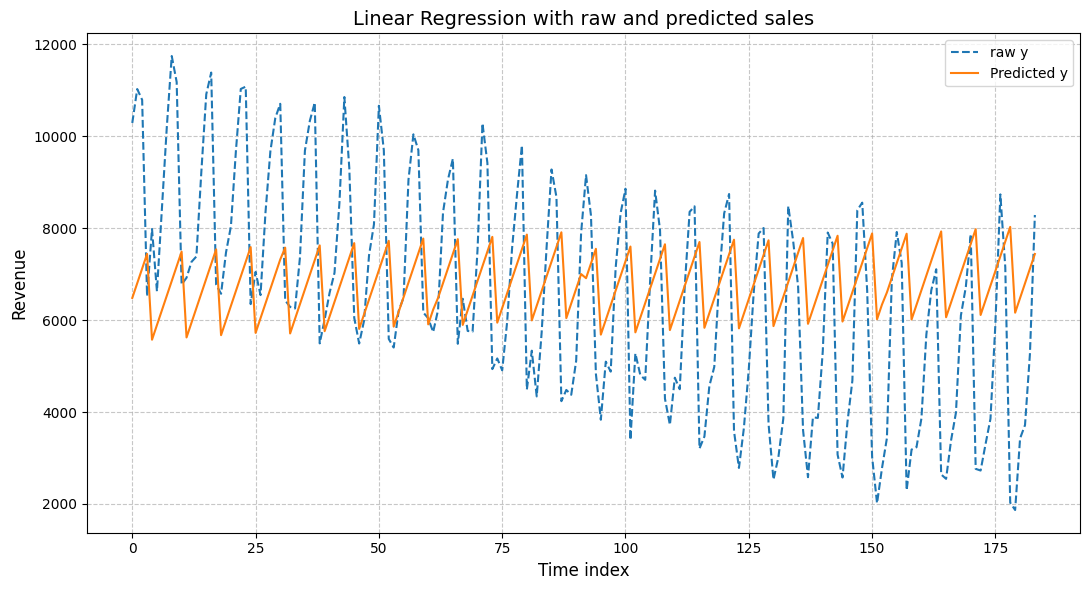

In [173]:
plt.figure(figsize = (11,6))

plt.plot(y_test.values, label='raw y', linestyle = '--')
plt.plot(y_predicted_on_test_data_linear_regression_model, label = 'Predicted y')

plt.title('Linear Regression with raw and predicted sales', fontsize = 14)
plt.xlabel('Time index', fontsize = 12)
plt.ylabel('Revenue', fontsize = 12)
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

#### Use Random Forest Model for training and testing

In [175]:
# Use Random Forest Model for training and testing

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(n_estimators = 220, random_state = 42)
random_forest_model.fit(X_train, y_train)
y_predicted_on_test_data_random_forest_model = random_forest_model.predict(X_test)
roort_mean_squared_error_test_data_random_forest_model = np.sqrt(mean_squared_error(y_test, y_predicted_on_test_data_random_forest_model))

print('Root mean squared error in test data with Random Forest model:')
print(roort_mean_squared_error_test_data_random_forest_model)

Root mean squared error in test data with Random Forest model:
846.5050418984762


In [177]:
# Comparing raw y test values with corresponding predicted values

Comparing_raw_y_test_predicted_values = pd.DataFrame({'Raw y test valuess': y_test.values,
                                                      'y Predicted values': y_predicted_on_test_data_random_forest_model})
print(Comparing_raw_y_test_predicted_values.head(7))

   Raw y test valuess  y Predicted values
0            10290.33         9178.106227
1            11028.59        10804.120500
2            10793.51        10835.932955
3             6524.13         6122.365045
4             7983.57         6329.166955
5             6627.40         7128.620318
6             8432.33         7732.039136


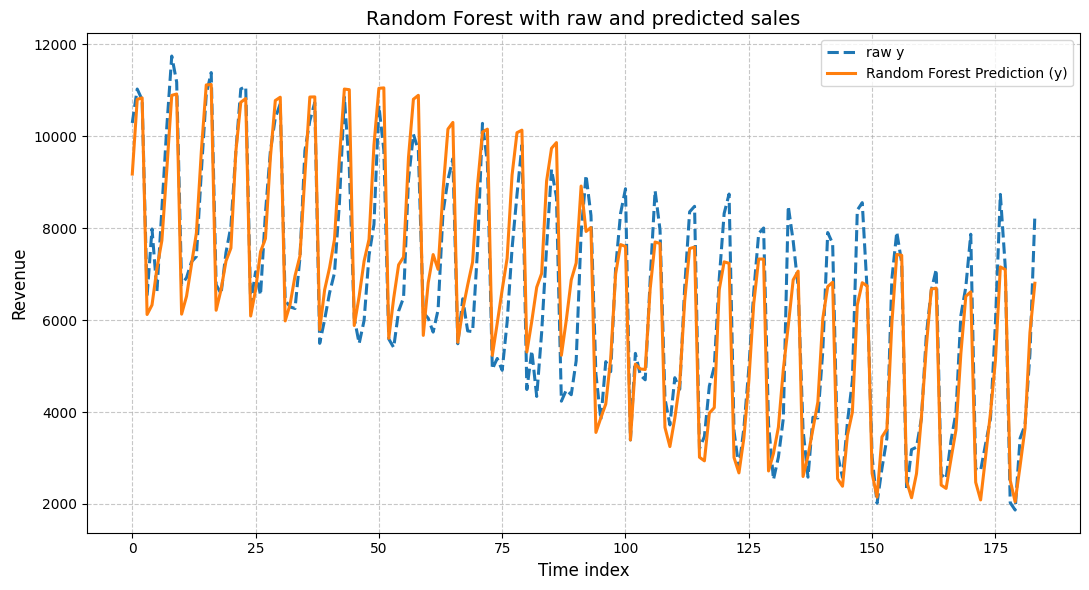

In [179]:
plt.figure(figsize = (11,6))

plt.plot(y_test.values, label = 'raw y', linestyle = '--', linewidth = 2.2)
plt.plot(y_predicted_on_test_data_random_forest_model, label = 'Random Forest Prediction (y)', linewidth = 2.2)
plt.title('Random Forest with raw and predicted sales', fontsize = 14)
plt.xlabel('Time index', fontsize = 12)
plt.ylabel('Revenue', fontsize = 12)

plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

#### Use XGBoost Model for training and testing

In [184]:
import xgboost as xgb

xgboost_model = xgb.XGBRegressor(n_estimators = 220, learning_rate = 0.1, random_state = 42)
xgboost_model.fit(X_train, y_train)
y_predicted_on_test_data_xgboost_model = xgboost_model.predict(X_test)
roort_mean_squared_error_test_data_xgboost_model = np.sqrt(mean_squared_error(y_test, y_predicted_on_test_data_xgboost_model))

print('Root mean squared error in test data with XGBoost model:')
print(roort_mean_squared_error_test_data_xgboost_model )

Root mean squared error in test data with XGBoost model:
701.7684208250753


In [186]:
# Comparing raw y test values with corresponding predicted values

comparing_raw_y_test_predicted_values_xgb = pd.DataFrame({'Raw y test valuess': y_test.values,
                                                          'Predicted_XGB_values': y_predicted_on_test_data_xgboost_model})

print(comparing_raw_y_test_predicted_values_xgb.head(7))

   Raw y test valuess  Predicted_XGB_values
0            10290.33           9491.891602
1            11028.59          10661.248047
2            10793.51          10746.595703
3             6524.13           5698.970703
4             7983.57           6040.210449
5             6627.40           7112.194336
6             8432.33           8005.775391


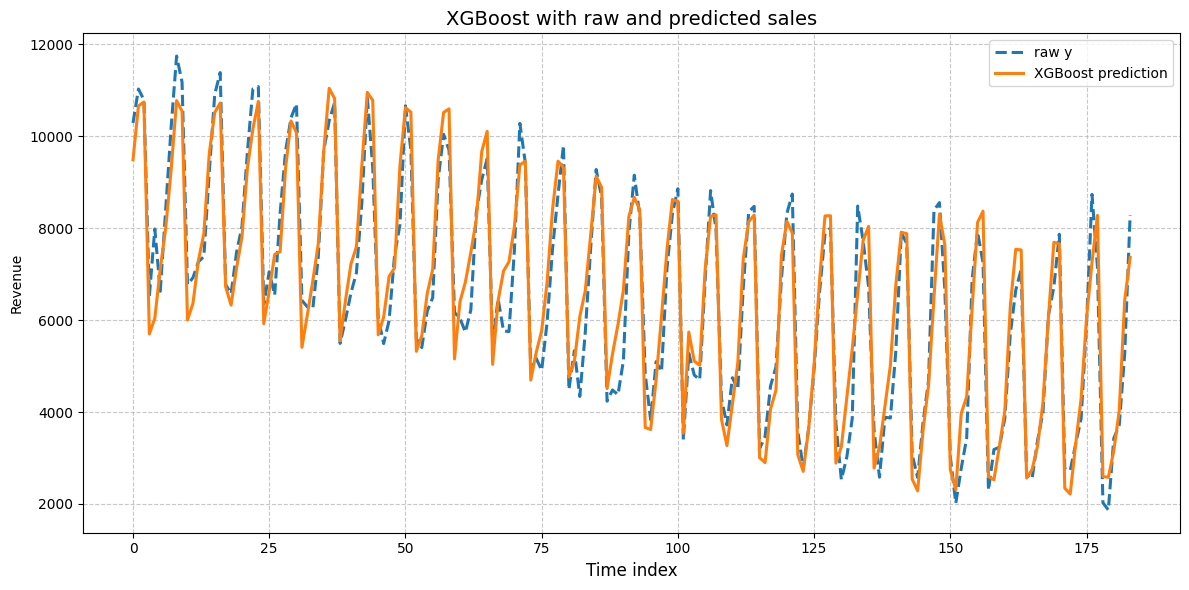

In [188]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='raw y', linestyle = '--', linewidth = 2.2)
plt.plot(y_predicted_on_test_data_xgboost_model, label = 'XGBoost prediction', linewidth = 2.2)

plt.title('XGBoost with raw and predicted sales', fontsize = 14)
plt.xlabel('Time index', fontsize = 12)
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

#### Compare model performances with RMSE

In [190]:

# Compare 3 models’ performances with RMSE

three_models_performances = pd.DataFrame({'model': ['Linear Regression', 'Random Forest', 'XGBoost'],
                             'RMSE': [roort_mean_squared_error_test_data_linear_regression_model,
                                           roort_mean_squared_error_test_data_random_forest_model,
                                           roort_mean_squared_error_test_data_xgboost_model]
                            })

print('Compare 3 models’ performances with RMSE:')
print()
print(three_models_performances)

Compare 3 models’ performances with RMSE:

               model         RMSE
0  Linear Regression  2391.696199
1      Random Forest   846.505042
2            XGBoost   701.768421


In [192]:
three_models_performances_sorted_values = three_models_performances.sort_values(by = 'RMSE')

print('Models performances RMSE sorted values:')
print()
print(three_models_performances_sorted_values)

Models performances RMSE sorted values:

               model         RMSE
2            XGBoost   701.768421
1      Random Forest   846.505042
0  Linear Regression  2391.696199


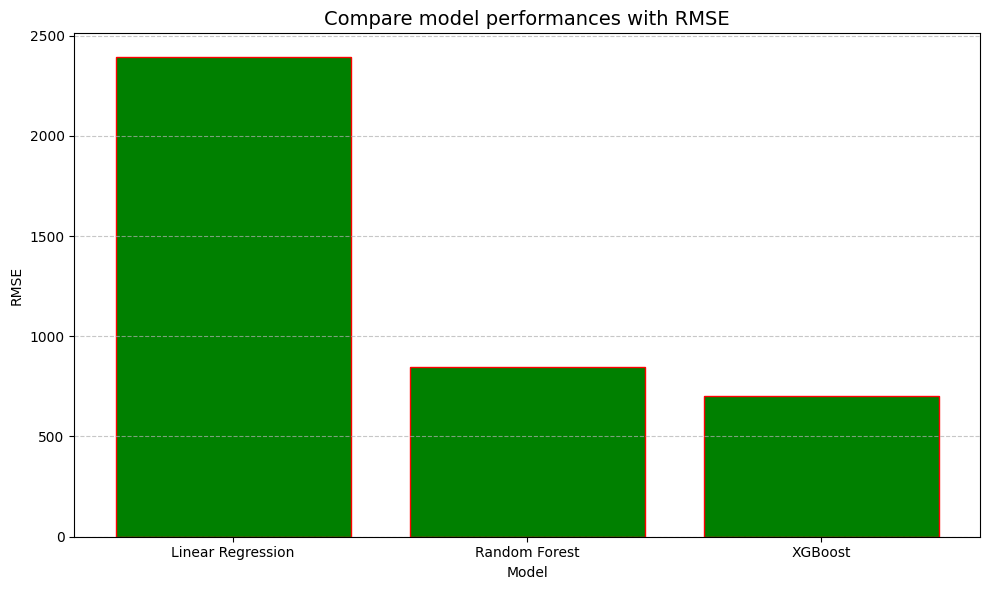

In [194]:
plt.figure(figsize = (10,6))

plt.bar(three_models_performances['model'], three_models_performances['RMSE'], color = 'green', edgecolor = 'red')

plt.title('Compare model performances with RMSE', fontsize=14)
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

 ### Use the best-performing models to make a forecast for the next year

In [198]:
# Forecast for the next year with best trained model (XGBoost)

best_trained_model = xgboost_model
 
# Find last date in dataset
last_date_current_year = total_sales_per_day['date'].max()
# Generate 365 days for the next year
next_year_365_days = pd.date_range(start = last_date_current_year + pd.Timedelta(days = 1), periods = 365)

forecast_data_frame = pd.DataFrame({'date': next_year_365_days})

# Create features to make a forecast for the next year
forecast_data_frame['year'] = forecast_data_frame['date'].dt.year
forecast_data_frame['month'] = forecast_data_frame['date'].dt.month
forecast_data_frame['day_of_month'] = forecast_data_frame['date'].dt.day
forecast_data_frame['day_of_week'] = forecast_data_frame['date'].dt.dayofweek
forecast_data_frame['quarter'] = forecast_data_frame['date'].dt.quarter

forecast_features = ['year', 'month', 'day_of_month', 'day_of_week', 'quarter']

X_forecast_features = forecast_data_frame[forecast_features]

# Predict future sales
forecast_data_frame['predicted_revenue'] = best_trained_model.predict(X_forecast_features )

print("Next 10 days predicted sales:")
print()
print(forecast_data_frame.head(10))

Next 10 days predicted sales:

        date  year  month  day_of_month  day_of_week  quarter  \
0 2022-01-01  2022      1             1            5        1   
1 2022-01-02  2022      1             2            6        1   
2 2022-01-03  2022      1             3            0        1   
3 2022-01-04  2022      1             4            1        1   
4 2022-01-05  2022      1             5            2        1   
5 2022-01-06  2022      1             6            3        1   
6 2022-01-07  2022      1             7            4        1   
7 2022-01-08  2022      1             8            5        1   
8 2022-01-09  2022      1             9            6        1   
9 2022-01-10  2022      1            10            0        1   

   predicted_revenue  
0        7310.373535  
1        2763.066162  
2        2348.401123  
3        3203.505127  
4        3449.844727  
5        5090.394531  
6        6577.524414  
7        6426.059082  
8        2649.762207  
9        2138.208496  


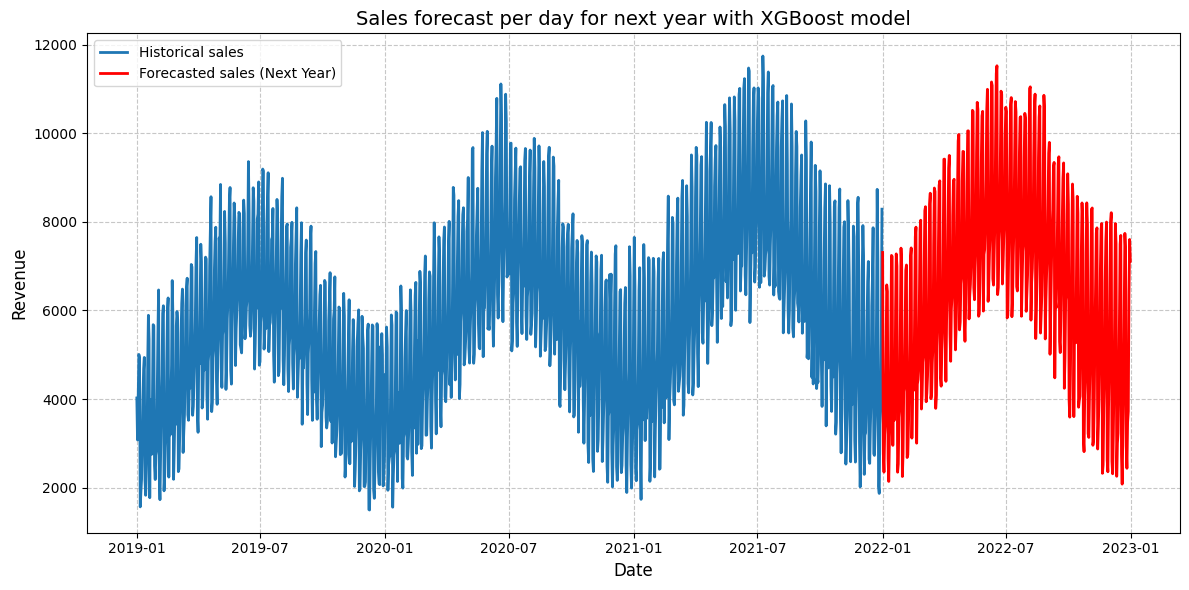

In [200]:
plt.figure(figsize = (12,6))

# past data
plt.plot(total_sales_per_day['date'], total_sales_per_day['revenue'], label = 'Historical sales',linewidth = 2)

# Forecast data
plt.plot(forecast_data_frame['date'], forecast_data_frame['predicted_revenue'], label = 'Forecasted sales (Next Year)', color = 'red',linewidth = 2)

plt.title('Sales forecast per day for next year with XGBoost model', fontsize = 14)
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Revenue', fontsize = 12)
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()